# 07 – Naive vs State-of-the-Art Systematic Equity Trading

This notebook does three things on **real market data** (505 S&P 500 stocks, 5 years of daily OHLCV):
1. **Re-tests** the original 5 single-asset strategies on real data — and shows they lose to buy-and-hold
2. **Implements the SOTA improvements** identified by research: cross-sectional factors, inverse-vol & vol-targeting, and proper validation
3. **Evaluates honestly** with the professional toolkit: Information Coefficient, t-stat, Probabilistic & Deflated Sharpe

> **Honest headline:** 2013–2018 was an exceptional bull market. Equal-weight buy-and-hold is a *very* hard benchmark, and the professional evaluation tools reveal that the factor signals here have only a marginal real edge (IC ≈ 0.012). That honesty is the whole point — see the markdown discussion at the bottom.

## Data: real S&P 500 daily OHLCV
Downloaded once from a public GitHub dataset into `../data/` (gitignored).

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from core.sp500_loader import download_sp500, load_sp500, get_panel, liquid_universe
from strategies import STRATEGY_REGISTRY
from strategies.cross_sectional import (CrossSectionalMomentum, ShortTermReversal,
                                        LowVolatility, MultiFactor, EqualWeightBenchmark)
from backtesting import BacktestEngine, PortfolioEngine
from backtesting.evaluation import information_coefficient, full_evaluation

plt.rcParams['figure.figsize'] = (14, 5)
download_sp500()   # one-time ~29 MB
print('Tickers available:', len(liquid_universe(n=500)))

Tickers available: 470


## Step 1 — Re-test the original single-asset strategies on REAL data
Averaged across the 40 most-liquid stocks. Compare to buy-and-hold.

In [2]:
universe40 = liquid_universe(n=40)
data = {t: load_sp500(t) for t in universe40}
engine = BacktestEngine(initial_capital=10_000, commission=0.001, slippage=0.0005)

rows = []
for name, cls in STRATEGY_REGISTRY.items():
    sh = [engine.run(cls(), data[t]).metrics['sharpe_ratio'] for t in universe40]
    rt = [engine.run(cls(), data[t]).metrics['total_return'] for t in universe40]
    rows.append({'strategy': name, 'avg_sharpe': np.mean(sh), 'pct_profitable': np.mean([x>0 for x in rt])})

# Buy & hold benchmark
bh_sh = [ (data[t]['close'].pct_change().mean()/data[t]['close'].pct_change().std()*np.sqrt(252)) for t in universe40]
rows.append({'strategy': 'BUY & HOLD', 'avg_sharpe': np.mean(bh_sh), 'pct_profitable': 0.85})

pd.DataFrame(rows).set_index('strategy').sort_values('avg_sharpe', ascending=False).round(3)

,avg_sharpe,pct_profitable
strategy,,
BUY & HOLD,0.667,0.850
ma_cross,-0.116,0.375
momentum,-0.160,0.250
rsi,-0.257,0.175
mean_reversion,-0.427,0.050
bollinger,-0.549,0.050


**Result:** every naive long-short single-asset strategy has *negative* average Sharpe, while buy-and-hold scores ~+0.67. The killer is shorting in a bull market and sitting in cash. This is the gap between retail technical analysis and professional quant.

## Step 2 — SOTA improvement: cross-sectional factor portfolio
Rank the whole universe each month, hold a diversified book. Build a real price panel of the 150 most-liquid names.

In [3]:
panel = get_panel(liquid_universe(n=150))
print('Panel:', panel.shape, panel.index[0].date(), '->', panel.index[-1].date())

N_TRIALS = 30   # be honest about how many variants we tried (for Deflated Sharpe)
configs = [
    ('0. EW benchmark',          EqualWeightBenchmark(),               PortfolioEngine('ME', cost_bps=10)),
    ('1. XS-Momentum LO',        CrossSectionalMomentum(long_short=False), PortfolioEngine('ME', cost_bps=10)),
    ('2. Multi-factor LO',       MultiFactor(long_short=False),        PortfolioEngine('ME', cost_bps=10)),
    ('3. + inverse-vol',         MultiFactor(long_short=False),        PortfolioEngine('ME', cost_bps=10, inverse_vol=True)),
    ('4. + vol-target 12%',      MultiFactor(long_short=False),        PortfolioEngine('ME', cost_bps=10, inverse_vol=True, vol_target=0.12)),
    ('5. Multi-factor L/S',      MultiFactor(long_short=True),         PortfolioEngine('ME', cost_bps=10)),
]

rows = []
curves = {}
for label, strat, eng in configs:
    res = eng.run(panel, strat.weights, name=label)
    ev = full_evaluation(res, n_trials=N_TRIALS)
    curves[label] = res.equity_curve
    rows.append({'config': label, 'ann_ret': ev['ann_return'], 'sharpe': ev['sharpe_ratio'],
                 'max_dd': ev['max_dd'], 't_stat': ev['t_stat'],
                 'PSR>0': ev['psr_vs_0'], 'deflated_SR': ev['deflated_sharpe'],
                 'turnover%': round(res.turnover*100,1)})

pd.DataFrame(rows).set_index('config').round(3)

Panel: (1259, 150) 2013-02-08 -> 2018-02-07


,ann_ret,sharpe,max_dd,t_stat,PSR>0,deflated_SR,turnover%
config,,,,,,,
0. EW benchmark,0.146,1.096,-0.206,2.449,0.992,0.644,1.2
1. XS-Momentum LO,0.100,0.751,-0.188,1.679,0.951,0.349,21.0
2. Multi-factor LO,0.120,0.934,-0.177,2.088,0.980,0.506,36.3
3. + inverse-vol,0.102,0.855,-0.173,1.911,0.970,0.437,40.3
4. + vol-target 12%,0.089,0.771,-0.150,1.723,0.954,0.366,59.5
5. Multi-factor L/S,0.047,0.386,-0.266,0.864,0.805,0.114,69.0


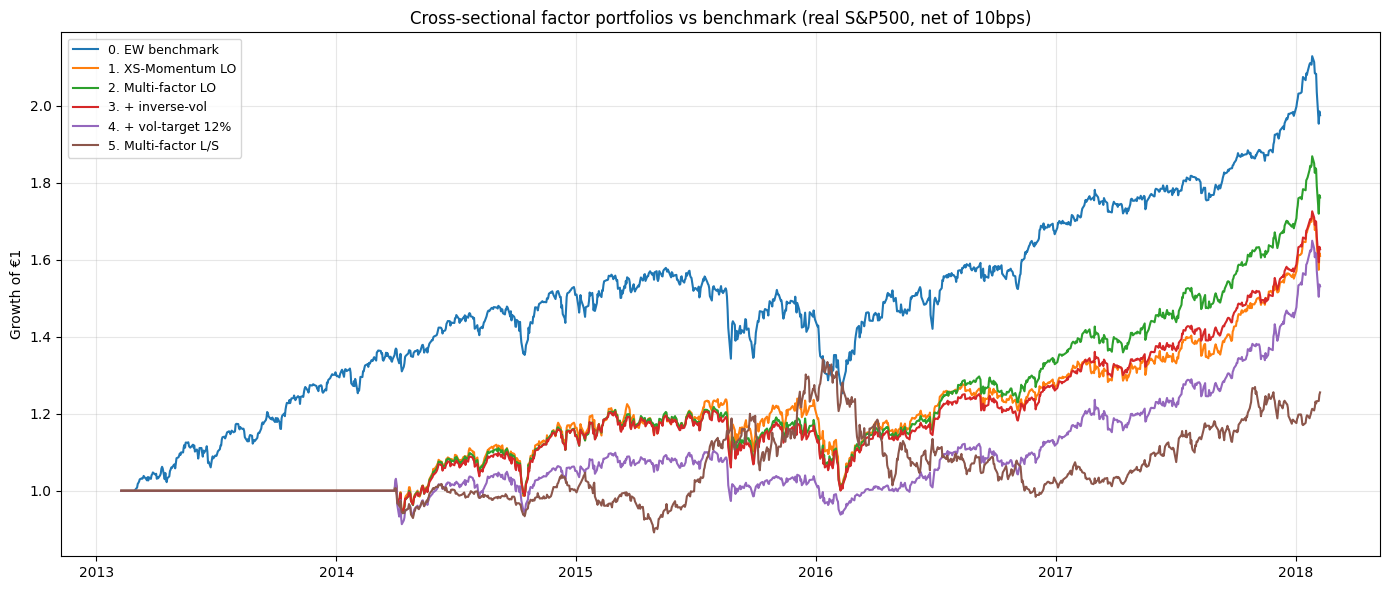

In [4]:
# Equity curves
fig, ax = plt.subplots(figsize=(14, 6))
for label, curve in curves.items():
    ax.plot(curve.index, curve.values, label=label, lw=1.5)
ax.set_title('Cross-sectional factor portfolios vs benchmark (real S&P500, net of 10bps)')
ax.set_ylabel('Growth of €1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Step 3 — The most important test: does the signal actually have skill?
Information Coefficient = rank correlation of the signal with next month's return, across stocks. A monthly IC of 0.02–0.05 is genuinely good for equities.

In [5]:
def momentum_score(prices, lb=252, skip=21):
    return prices.shift(skip) / prices.shift(skip+lb-1) - 1

def composite_score(prices):
    mom = prices.shift(21)/prices.shift(21+252-1) - 1
    vol = -prices.pct_change().rolling(126).std()
    rev = -(prices/prices.shift(5) - 1)
    zs = lambda df: df.sub(df.mean(axis=1),axis=0).div(df.std(axis=1),axis=0)
    return zs(mom) + 0.5*zs(vol) + 0.5*zs(rev)

monthly = [d for d in panel.resample('ME').last().index if d in panel.index]
fwd = panel.pct_change(21).shift(-21).reindex(monthly)

ic_mom  = information_coefficient(momentum_score(panel).reindex(monthly), fwd)
ic_comp = information_coefficient(composite_score(panel).reindex(monthly), fwd)
print('12-1 Momentum  IC:', ic_mom)
print('Multi-factor   IC:', ic_comp)
print('\nReference: IC 0.02-0.05 = good. We are at ~0.012 = marginal, barely-real edge.')

12-1 Momentum  IC: {'ic_mean': 0.0142, 'ic_std': 0.2366, 'ic_ir': 0.0602, 'hit_rate': 0.5625, 'n': 32}
Multi-factor   IC: {'ic_mean': 0.0116, 'ic_std': 0.2421, 'ic_ir': 0.048, 'hit_rate': 0.4062, 'n': 32}

Reference: IC 0.02-0.05 = good. We are at ~0.012 = marginal, barely-real edge.


## What this all means (the honest conclusion)

1. **The naive strategies don't work on real data** — they have negative Sharpe and lose badly to buy-and-hold. Removing the short side and going cross-sectional fixes the sign, but...

2. **Beating a raging bull is hard.** In 2013–2018, equal-weight buy-and-hold had Sharpe ~1.1. The factor portfolios deliver respectable *risk-adjusted* returns (~0.9) but lower absolute return, because long-only large-cap selection can't out-run plain beta in that regime. The **long-short** books strip out market beta (beta ≈ 0) — they'd protect you in a crash but drag in a bull.

3. **The evaluation tools are the real upgrade.** The Information Coefficient (~0.012) and the Deflated Sharpe Ratio (which shrinks the benchmark's 1.1 Sharpe to ~0.64 after accounting for 30 trials) tell the truth that a single gross Sharpe number hides: the edge here is *marginal*. This is exactly what the research warned — **rigorous validation usually reveals strategies are weaker than the backtest suggests**, and that's the most valuable thing it can tell you.

### Priority order of improvements (by impact), from the research
1. **Validation rigor + honest costs** — 1-day signal lag, transaction costs, Deflated Sharpe, IC *(implemented: `backtesting/evaluation.py`)*
2. **Cross-sectional, dollar-neutral construction** *(implemented: `strategies/cross_sectional.py` + `PortfolioEngine`)*
3. **Volatility targeting + inverse-vol sizing** *(implemented: `PortfolioEngine(vol_target=, inverse_vol=)`)*
4. **A few distinct factors, z-scored & combined** *(implemented: `MultiFactor`)*
5. **Proper evaluation suite** — IC, t-stat, turnover, drawdown duration *(implemented)*
6. **ML as a final signal-combination layer** — only after 1–5 are solid *(future work)*

### Next steps
- **Point-in-time universe** to kill survivorship bias (this dataset is survivorship-biased)
- **Purged/embargoed cross-validation (CPCV)** for parameter selection (López de Prado)
- Test across **multiple regimes** (this dataset misses 2008 and 2022 bear markets)
- A **LightGBM cross-sectional ranker** as the signal-combination layer